# Домашнее задание №7

## Реализовать метрики: Precision@k, Recall@k, mAP (1 балл)

In [85]:
import random
import os

import tqdm
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from torch.utils.data import Dataset, DataLoader
from pytorch_metric_learning import miners, losses
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import faiss

In [2]:
def precision_at_k(relevance, k):
    return np.sum(relevance[:k]) / k

In [3]:
precision_at_k([1, 1, 0, 0, 1, 0, 1], 3)

np.float64(0.6666666666666666)

In [80]:
def recall_at_k(relevance, k):
    if np.sum(relevance) == 0.0:
        return np.float32(0.0)
    return np.sum(relevance[:k]) / np.sum(relevance)

In [5]:
recall_at_k([1, 1, 0, 0, 1, 0, 1], 3)

np.float64(0.5)

In [6]:
def average_precision_at_k(relevance, k):
    result = 0.0
    for i in range(1, k+1):
        result += precision_at_k(relevance, i) * relevance[i-1]
    return result / k

In [7]:
average_precision_at_k([1, 1, 0, 0, 1, 0, 1], 3)

np.float64(0.6666666666666666)

In [8]:
average_precision_at_k([0, 1, 1, 0, 1, 0, 1], 3)

np.float64(0.38888888888888884)

In [9]:
def map_at_k(relevance_list, k):
    result = 0.0
    for relevance in relevance_list:
        result += average_precision_at_k(relevance, k)
    return result / len(relevance_list)

In [10]:
map_at_k(
    [
        [1, 1, 0, 0, 1, 0, 1],
        [0, 1, 1, 0, 1, 0, 1],
        [0, 0, 0, 1, 1],
        [1, 1, 1, 1, 1, 1]
    ],
    3
)

np.float64(0.5138888888888888)

# Добавить train аугментации (1 балл)

In [11]:
mat = scipy.io.loadmat('data/devkit/cars_train_annos.mat')
fname_to_class = {fname:cl-1 for fname, cl in zip([i[0] for i in mat['annotations'][0]['fname']], 
                                                [i[0][0] for i in mat['annotations'][0]['class']])}
cars_meta = scipy.io.loadmat('data/devkit/cars_meta.mat')
id_to_car = {idx: car[0] for idx, car in enumerate(cars_meta['class_names'][0])}

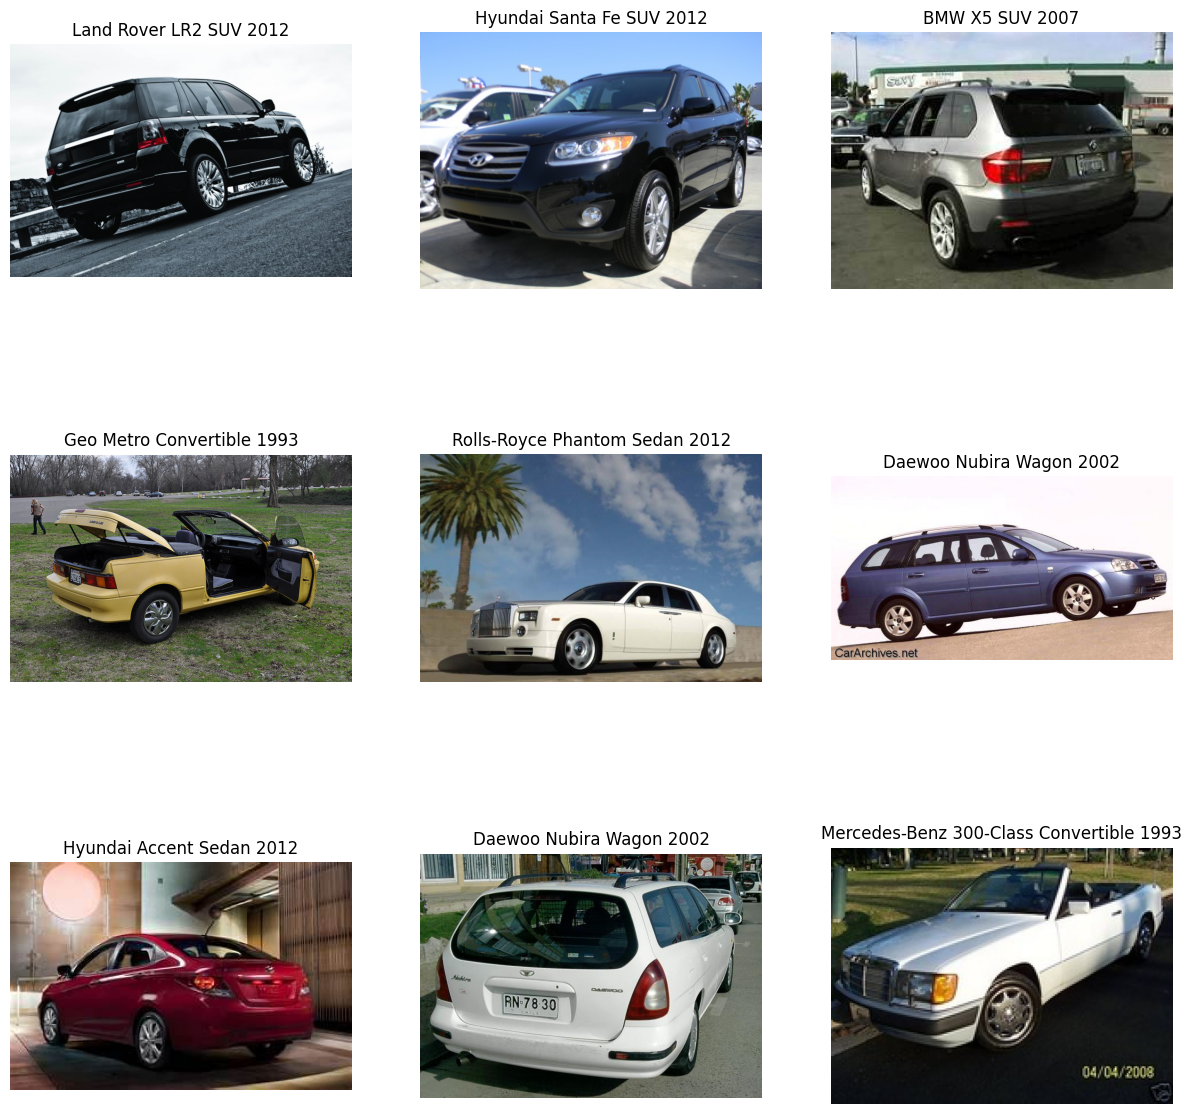

In [12]:
ADD_PATH = 'data/cars_train'
num_imgs = 9
cols = 3
rows = num_imgs // cols
fig, ax = plt.subplots(rows, cols, figsize = (15, 15))
for idx, im_idx in enumerate(random.sample([i for i in range(len(fname_to_class))], num_imgs)):
    filename, cl_id = list(fname_to_class.items())[im_idx]
    temp_image = cv2.imread(os.path.join(ADD_PATH, filename))
    temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB)
    ax[idx//cols][idx%cols].imshow(temp_image)
    ax[idx//cols][idx%cols].set_title(f'{id_to_car[cl_id]}')
    ax[idx//cols][idx%cols].axis('off')

In [13]:
train_transforms = transforms.Compose([
            transforms.ToPILImage(), 
            transforms.Resize(
                size=(224, 224)
            ),
            transforms.RandomRotation((-10, 10)),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),  
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]   
            )
            ])

val_transforms = transforms.Compose([
            transforms.ToPILImage(), 
            transforms.Resize(
                size=(224, 224)
            ),
            transforms.ToTensor(),  
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            ])

class CarsDataset(Dataset):
    def __init__(self, cars_items, transforms):
        self.cars = cars_items
        self.transforms = transforms
        
    def __len__(self):
        return len(self.cars)

    def __getitem__(self, idx):
        filename, cl_id = self.cars[idx]
        image = cv2.imread(os.path.join(ADD_PATH, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        sample = {'image': image, 'label': cl_id}
        return sample

In [14]:
items = list(fname_to_class.items())
random.shuffle(items)
train_items = items[:int(len(items) * 0.8)]
val_items = items[int(len(items) * 0.8):]

train_dataset = CarsDataset(train_items, train_transforms)
val_dataset = CarsDataset(val_items, val_transforms)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=None, pin_memory=True, drop_last = True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=None, pin_memory=True)

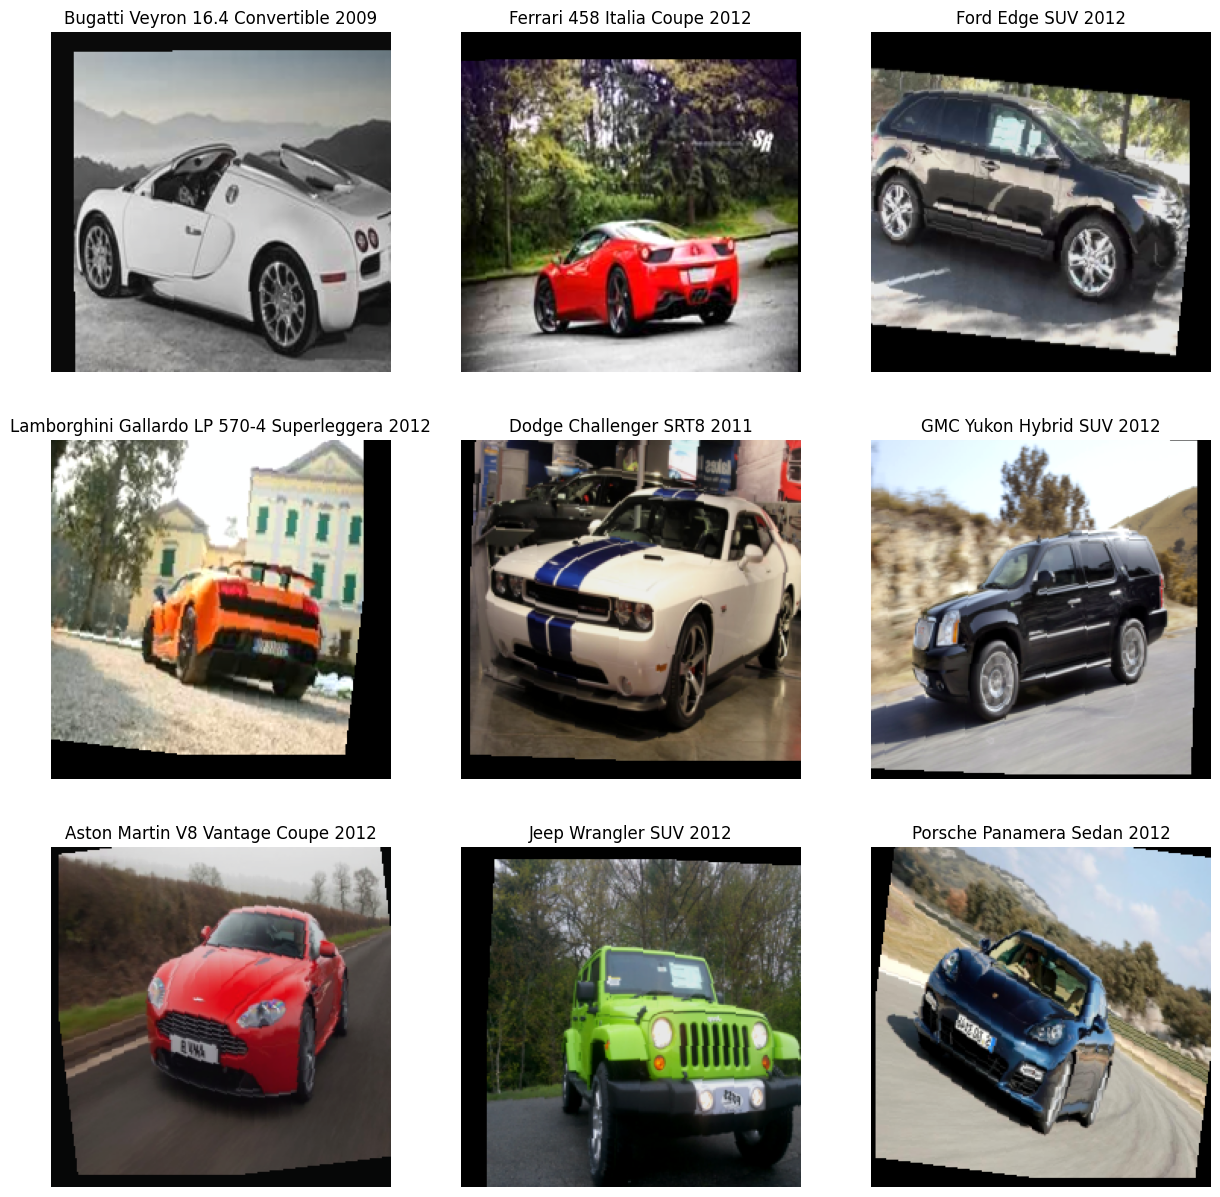

In [16]:
num_imgs = 9
cols = 3
rows = num_imgs // cols
fig, ax = plt.subplots(rows, cols, figsize = (15, 15))
for i in range(9):
    data = train_dataset[i]
    image = data["image"]
    label = data["label"]
    image = image.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    ax[i//cols][i%cols].imshow(image)
    ax[i//cols][i%cols].set_title(f'{id_to_car[label]}')
    ax[i//cols][i%cols].axis('off')

аугментации работают

## Обучить модель (2 балла)

- При обучении использовать backbone отличный от того, что использовался на семинаре (не ResNet50)
- Добавить triplet-loss (помните о грамотном формировании триплетов)
- Рассчитать метрики из п.1

In [17]:
model = efficientnet_b0(pretrained=True)
model

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [18]:
class CarEmbedder(pl.LightningModule):
    def __init__(self, class_dict, learning_rate, emb_size):
        super().__init__()
        self.learning_rate = learning_rate
        
        self.model = efficientnet_b0(pretrained=True)
        
        self.model.classifier[1] = nn.Linear(in_features=1280, out_features=emb_size)
        
        self.triplet_miner = miners.TripletMarginMiner(type_of_triplets="hard")
        self.triplet_loss = losses.TripletMarginLoss()

        self.save_hyperparameters()

    def training_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        preds = self.model(images)
        
        hard_pairs = self.triplet_miner(preds, labels)
        final_loss = self.triplet_loss(preds, labels, hard_pairs)
        
        self.log("train_loss", final_loss, sync_dist=True)
        return final_loss
    
    def validation_step(self, batch, batch_idx):
        images = batch['image']
        labels = batch['label'].to(torch.long)
        preds = self.model(images)

        hard_pairs = self.triplet_miner(preds, labels)
        final_loss = self.triplet_loss(preds, labels, hard_pairs)

        self.log("validation_loss", final_loss, sync_dist=True)
        
    def forward(self, images):
        if len(images.shape) == 4:
            preds = self.model(images) 
        else:
            preds = self.model(images.unsqueeze(0))
        return preds
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return [optimizer]

In [19]:
# model
pl_model = CarEmbedder(id_to_car, 3e-4, 512)
checkpoint_callback = ModelCheckpoint(monitor='validation_loss',mode='min',  save_top_k=3)
early_stopping = EarlyStopping(monitor="validation_loss", mode="min", patience=2)
lr_monitor = LearningRateMonitor(logging_interval='step')

device = "cpu"

# train model
trainer = pl.Trainer(
    max_epochs=10,
    accelerator=device,
    devices=1,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor])

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [20]:
trainer.fit(model=pl_model, train_dataloaders=train_loader, 
            val_dataloaders=valid_loader)


  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | model         | EfficientNet       | 4.7 M  | train
1 | triplet_miner | TripletMarginMiner | 0      | train
2 | triplet_loss  | TripletMarginLoss  | 0      | train
-------------------------------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.654    Total estimated model params size (MB)
342       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 2: 100%|██████████| 101/101 [10:49<00:00,  0.16it/s, v_num=5]


In [21]:
trainer.validate(model=pl_model, dataloaders=valid_loader)

Validation DataLoader 0: 100%|██████████| 26/26 [00:44<00:00,  0.59it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     validation_loss        0.1414385437965393
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'validation_loss': 0.1414385437965393}]

Построим индекс

In [22]:
torch.save(pl_model.model.state_dict(), "weights.dat")

In [20]:
pl_model.model.load_state_dict(torch.load("weights.dat"))

<All keys matched successfully>

In [22]:
pl_model.eval()

CarEmbedder(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_act

In [25]:
def get_embeds(model, loader):
    embeddings = np.empty((1,512))
    labels = np.empty((1))
    for batch in tqdm.tqdm(loader):
        imgs = batch['image']
        label = batch['label']
        with torch.no_grad():
            preds = model(imgs.to(device))
        embeddings = np.concatenate([embeddings, preds.cpu().numpy()])
        labels = np.concatenate([labels, label.numpy()])
    return embeddings[1:].astype(np.float32), labels[1:]

In [26]:
train_emb, train_labels = get_embeds(pl_model, train_loader)
val_emb, val_labels = get_embeds(pl_model, valid_loader)

  0%|          | 0/101 [00:00<?, ?it/s]d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 26/26 [00:48<00:00,  1.88s/it]


In [27]:
train_emb.shape

(6464, 512)

In [30]:
index = faiss.IndexFlatL2(512)   # build the index
print(index.is_trained)
index.add(train_emb)                  # add vectors to the index
print(index.ntotal)

k = 4                          # we want to see 4 nearest neighbors
D, I = index.search(train_emb[:5], k) # sanity check
print(I)
print(D)
D, I = index.search(val_emb, k)     # actual search
print(I[:5])                   # neighbors of the 5 first queries
print(I[-5:]) 

True
6464
[[   0 4016 4865 2001]
 [   1 3913 6220 1006]
 [   2 1073 4861  175]
 [   3 3123 1383 3357]
 [   4 4349 5723 4702]]
[[ 0.       28.45057  28.471302 28.701603]
 [ 0.       44.04283  45.453575 45.595234]
 [ 0.       37.373196 37.93995  38.345314]
 [ 0.       27.382378 33.69828  33.85214 ]
 [ 0.       39.119526 39.379845 39.839565]]
[[6114 6005 3575 5127]
 [4241 2446 4502 3002]
 [5088 3460  873 3374]
 [5248  309 4947 4401]
 [5042 2779 3087 4055]]
[[2698 6413 1789 3233]
 [1386 3540 1755 5574]
 [1604 5894 5680 3501]
 [4190 5667 1610 4346]
 [5349 2836  395 5822]]


Расчитаем Precision@10, Recall@10 и AveragePrecision@10 для первых 5 объектов из валидации

In [75]:
Distances, Indexes = index.search(val_emb[:5], 20)

In [76]:
Indexes

array([[6114, 6005, 3575, 5127, 2430, 2480, 5929, 2933, 6006, 1054, 3096,
        5200, 1487, 3208,  567, 2037, 3844, 5220, 2166, 4946],
       [4241, 2446, 4502, 3002, 3611, 6058, 6125, 1326, 4741, 2451, 1204,
        2887, 2663, 3064, 5816, 1821, 3875, 5433, 6177, 5642],
       [5088, 3460,  873, 3374,  102, 6072, 6328, 1418,  257, 1724, 4540,
        1672, 1287, 2252, 4902, 1400, 2799, 5526, 6248, 2343],
       [5248,  309, 4947, 4401, 6015, 5260, 2105, 1862, 5605, 3937, 1892,
          56,  456, 3870,  552, 5000, 2156, 4464,  338, 4851],
       [5042, 2779, 3087, 4055, 2656, 2233,  438, 4141, 4817, 1232, 1619,
        5898, 3874, 3006, 5295, 4943,  529, 6280,  347, 3468]])

In [77]:
Distances

array([[16.761938, 18.209879, 19.078379, 20.588135, 21.05207 , 21.16928 ,
        21.533424, 22.065514, 22.069998, 22.132347, 22.742607, 23.422728,
        23.481964, 23.487232, 23.716167, 23.861485, 24.465857, 24.61873 ,
        25.418203, 25.501633],
       [31.21716 , 33.015167, 33.021065, 33.674263, 33.87033 , 34.910683,
        35.426785, 35.80632 , 36.227203, 36.261932, 36.5416  , 36.544563,
        36.592197, 36.663437, 37.118576, 37.36108 , 37.37017 , 37.379578,
        37.65552 , 37.793716],
       [21.806591, 23.534254, 23.727654, 23.810116, 24.147219, 24.151348,
        24.19503 , 24.423967, 24.436897, 24.484203, 24.671307, 24.741684,
        24.773836, 24.827902, 24.93372 , 25.248337, 25.363304, 25.4766  ,
        25.508362, 25.534103],
       [20.963383, 21.556456, 22.013435, 22.305248, 23.513016, 23.928337,
        23.96164 , 24.070866, 24.087292, 24.409492, 24.488274, 24.526741,
        24.549644, 24.623472, 24.630095, 24.652122, 24.766094, 24.780396,
        24.82057 , 

In [78]:
relevance = val_labels[:5].reshape(-1, 1).repeat(20, axis=1) == train_labels[Indexes.flatten()].reshape(-1, 20)

In [81]:
for i in range(5):
    print(f"{i+1} object:")
    print(f'Precision@10 : {precision_at_k(relevance[i], 10)}')
    print(f'Recall@10 : {recall_at_k(relevance[i], 10)}')
    print(f'AveragePrecision@10 : {average_precision_at_k(relevance[i], 10)}')
    print("--------------------")

1 object:
Precision@10 : 0.4
Recall@10 : 0.8
AveragePrecision@10 : 0.35
--------------------
2 object:
Precision@10 : 0.1
Recall@10 : 0.5
AveragePrecision@10 : 0.03333333333333333
--------------------
3 object:
Precision@10 : 0.0
Recall@10 : 0.0
AveragePrecision@10 : 0.0
--------------------
4 object:
Precision@10 : 0.0
Recall@10 : 0.0
AveragePrecision@10 : 0.0
--------------------
5 object:
Precision@10 : 0.1
Recall@10 : 1.0
AveragePrecision@10 : 0.1
--------------------


Теперь расчитаем MAP@10

In [82]:
Distances, Indexes = index.search(val_emb, 20)

In [83]:
relevance = val_labels.reshape(-1, 1).repeat(20, axis=1) == train_labels[Indexes.flatten()].reshape(-1, 20)

In [84]:
print(f"MAP@10 : {map_at_k(relevance, 10)}")

MAP@10 : 0.08403139524686486


## Показать с помощью GradCAM, где ошибается модель (1 балл)

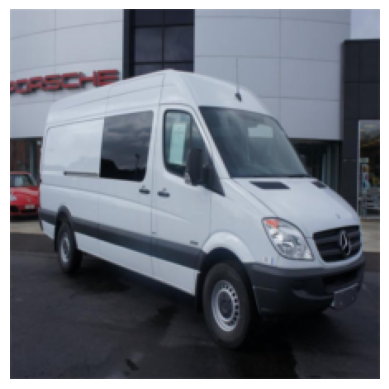

In [112]:
input_tensor = val_dataset[0]["image"].unsqueeze(0)
image = input_tensor.squeeze(0).permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = image * std + mean
image = np.clip(image, 0, 1)
plt.imshow(image)
plt.axis("off")
plt.show()

In [134]:
class SimilarityToConceptTarget:
    def __init__(self, features):
        self.features = torch.tensor(features)
    
    def __call__(self, model_output):
        cos = nn.CosineSimilarity(dim=0)
        return cos(model_output, self.features)

def where_car(emb, input_tensor, image):
    target_layers = [pl_model.model.features[-1]]
    car_targets = [SimilarityToConceptTarget(emb)]


    # Where is the car in the image
    with GradCAM(model=pl_model.model,
                target_layers=target_layers) as cam:
        car_grayscale_cam = cam(input_tensor=input_tensor,
                            targets=car_targets)[0, :]
    car_cam_image = show_cam_on_image(image, car_grayscale_cam, use_rgb=True)
    return Image.fromarray(car_cam_image)

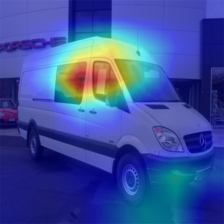

In [135]:
where_car(val_emb[0], input_tensor, image)

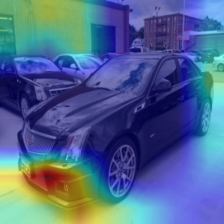

In [136]:
input_tensor = val_dataset[1]["image"].unsqueeze(0)
image = input_tensor.squeeze(0).permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = image * std + mean
image = np.clip(image, 0, 1)
where_car(val_emb[1], input_tensor, image)

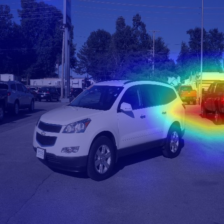

In [137]:
input_tensor = val_dataset[2]["image"].unsqueeze(0)
image = input_tensor.squeeze(0).permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = image * std + mean
image = np.clip(image, 0, 1)
where_car(val_emb[2], input_tensor, image)